# Titanic Dataset Analysis
**Project:** Data Analysis Project — Week 4, Data Science with Python
**Goal:** Explore the Titanic passenger dataset and find insights about who survived and why.


## 1. Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Data

In [4]:
from pathlib import Path
import ssl


def load_titanic_data():
    local_candidates = [
        Path("Titanic-Dataset.csv"),
        Path.cwd() / "Titanic-Dataset.csv",
    ]

    for candidate in local_candidates:
        if candidate.exists():
            return pd.read_csv(candidate)

    try:
        ssl._create_default_https_context = ssl._create_unverified_context
        return sns.load_dataset("titanic")
    except Exception:
        url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
        return pd.read_csv(url)


df = load_titanic_data()
rename_map = {
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
    "class": "Class",
    "who": "Who",
    "adult_male": "AdultMale",
    "deck": "Deck",
    "embark_town": "EmbarkTown",
    "alive": "Alive",
    "alone": "Alone",
    "name": "Name",
    "ticket": "Ticket",
    "cabin": "Cabin",
    "passengerid": "PassengerId",
    "passenger_id": "PassengerId",
}
df = df.rename(columns={old: new for old, new in rename_map.items() if old in df.columns})
if "PassengerId" not in df.columns:
    df.insert(0, "PassengerId", range(1, len(df) + 1))

print("Shape:", df.shape)
df.head()

Shape: (891, 16)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Class,Who,AdultMale,Deck,EmbarkTown,Alive,Alone
0,1,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,2,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,4,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,5,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Sex          891 non-null    str     
 4   Age          714 non-null    float64 
 5   SibSp        891 non-null    int64   
 6   Parch        891 non-null    int64   
 7   Fare         891 non-null    float64 
 8   Embarked     889 non-null    str     
 9   Class        891 non-null    category
 10  Who          891 non-null    str     
 11  AdultMale    891 non-null    bool    
 12  Deck         203 non-null    category
 13  EmbarkTown   889 non-null    str     
 14  Alive        891 non-null    str     
 15  Alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(5), str(5)
memory usage: 87.6 KB


In [6]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
Class            0
Who              0
AdultMale        0
Deck           688
EmbarkTown       2
Alive            0
Alone            0
dtype: int64

## 3. Clean the Data

- `Age` has 177 missing values → fill with the median age
- `Embarked` has 2 missing values → fill with the most common port
- `Cabin` is missing for most passengers → drop it (too sparse to be useful)
- Drop `Ticket`, `Name`, `PassengerId` → not useful for this analysis

In [7]:
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())
if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
for column in ["Cabin", "Ticket", "Name", "PassengerId"]:
    if column in df.columns:
        df = df.drop(columns=[column])

df.isnull().sum()

Survived        0
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Class           0
Who             0
AdultMale       0
Deck          688
EmbarkTown      2
Alive           0
Alone           0
dtype: int64

## 4. Explore Survival Patterns

In [8]:
overall_rate = df["Survived"].mean()
print(f"Overall survival rate: {overall_rate:.1%}")

Overall survival rate: 38.4%


In [9]:
by_sex = df.groupby("Sex")["Survived"].mean()
by_sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [10]:
by_class = df.groupby("Pclass")["Survived"].mean()
by_class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [11]:
by_class_sex = df.groupby(["Pclass", "Sex"])["Survived"].mean()
by_class_sex

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [12]:
df["AgeGroup"] = pd.cut(
    df["Age"], bins=[0, 12, 18, 35, 60, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)
by_age = df.groupby("AgeGroup", observed=True)["Survived"].mean()
by_age

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64

## 5. Visualize the Findings

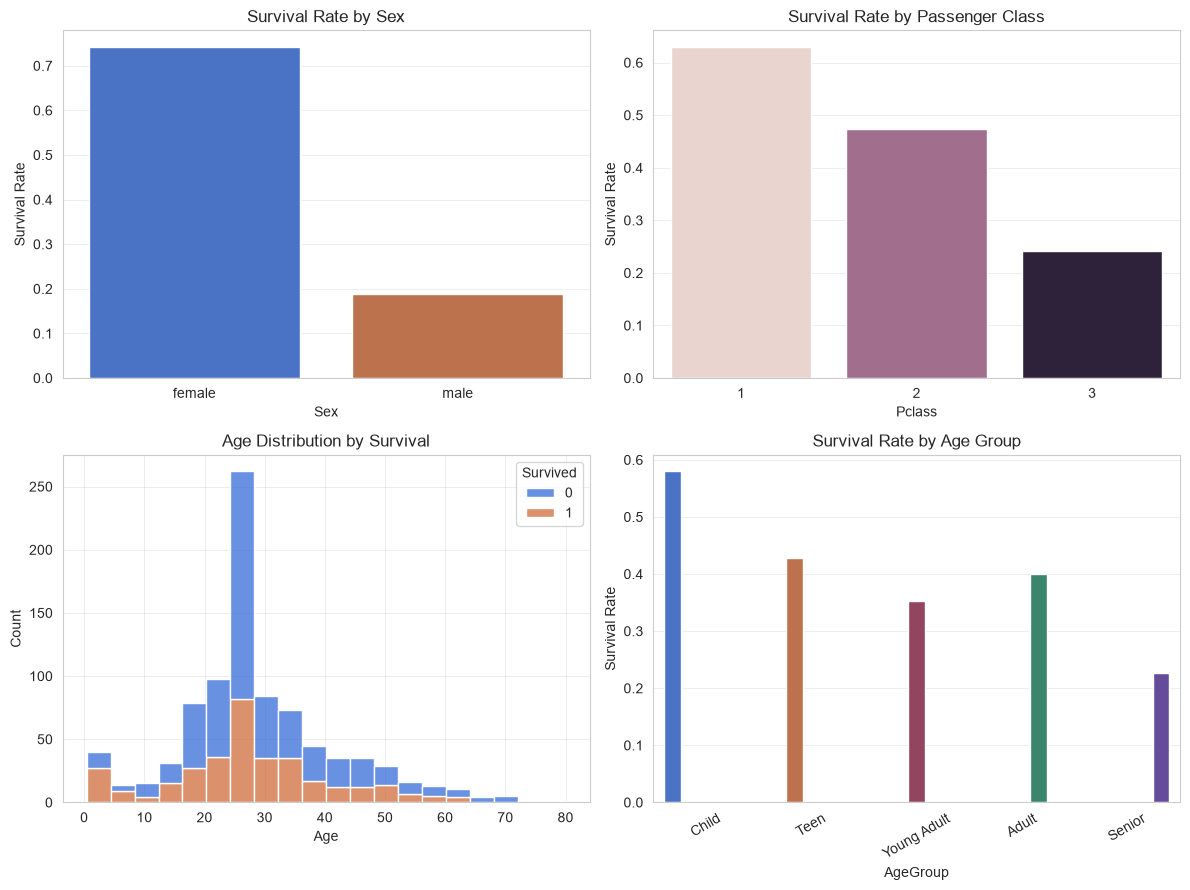

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(x=by_sex.index, y=by_sex.values, hue=by_sex.index, legend=False, ax=axes[0,0])
axes[0,0].set_title("Survival Rate by Sex")
axes[0,0].set_ylabel("Survival Rate")

sns.barplot(x=by_class.index, y=by_class.values, hue=by_class.index, legend=False, ax=axes[0,1])
axes[0,1].set_title("Survival Rate by Passenger Class")
axes[0,1].set_ylabel("Survival Rate")

sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", bins=20, ax=axes[1,0])
axes[1,0].set_title("Age Distribution by Survival")

sns.barplot(x=by_age.index, y=by_age.values, hue=by_age.index, legend=False, ax=axes[1,1])
axes[1,1].set_title("Survival Rate by Age Group")
axes[1,1].set_ylabel("Survival Rate")
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("titanic_charts.png", dpi=150)
plt.show()

## 6. Key Insights

1. **Sex was the strongest predictor of survival.** Women survived at ~74%, men at ~19%. This reflects the "women and children first" evacuation policy.
2. **Passenger class mattered a lot.** 1st class passengers survived at ~63%, vs. ~47% for 2nd class and ~24% for 3rd class — likely due to cabin location and lifeboat access.
3. **Class and sex compounded.** 1st class women survived at ~97%, while 3rd class men survived at only ~14% — the worst-off group by far.
4. **Children had a survival advantage.** Survival rate was highest for children (~58%) and lowest for seniors (~23%), consistent with priority evacuation for kids.
